Import Library

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import Dense

Konfigurasi

In [2]:
X_test_raw = np.load("X_test_raw.npy")
y_test     = np.load("y_test.npy")

model = load_model("model_CNN.h5")
model_woa = load_model("model_woa.h5")

TARGET_CRYSTAL_SYS = [0, 1, 2, 5]
CRYSTAL_SYS_MAP    = {0: "Kubik", 1: "Tetragonal", 2: "Ortorombik", 5: "Monoklinik"}
PALETTE = ["#2196F3", "#F32121", "#09F50D", "#DE21F3"]
RANDOM_SEED = 42

Labelling Encoding

In [3]:
le = LabelEncoder()
le.classes_ = np.array(sorted(TARGET_CRYSTAL_SYS))
y_test_enc  = le.transform(y_test)
CLASS_NAMES = [CRYSTAL_SYS_MAP[c] for c in le.classes_]

X_test_cnn = X_test_raw[..., np.newaxis]


Fungsi t-SNE

In [15]:
def extract_features_after_fc2_before_softmax(mdl, X_cnn):
    dense_layers = [layer for layer in mdl.layers if isinstance(layer, Dense)]
    if len(dense_layers) < 3:
        raise ValueError("Model harus memiliki minimal 3 Dense layer")
    
    fc2_layer = dense_layers[-2]
    feature_model = Model(inputs=mdl.input, outputs=fc2_layer.output)
    features = feature_model.predict(X_cnn, verbose=0)
    
    if features.ndim > 2:
        features = features.reshape(features.shape[0], -1)
    return features

t-SNE 2D

   Shape fitur : (1029, 16)
   Menjalankan t-SNE 2D ...


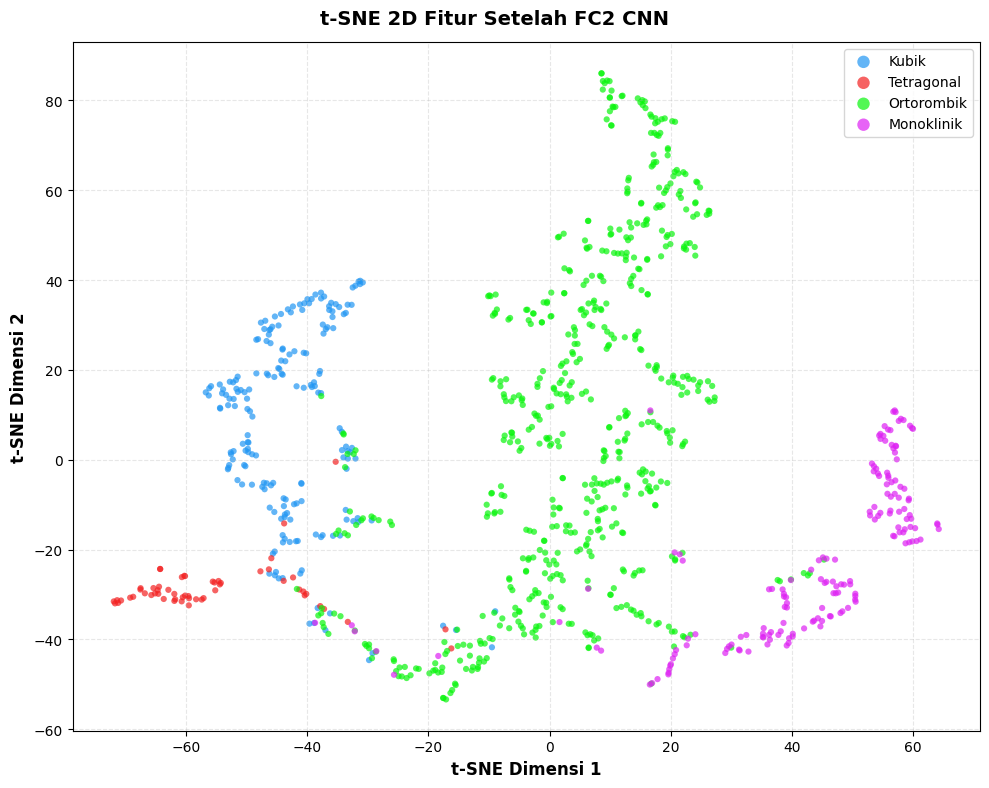

   Shape fitur : (1029, 64)
   Menjalankan t-SNE 2D ...


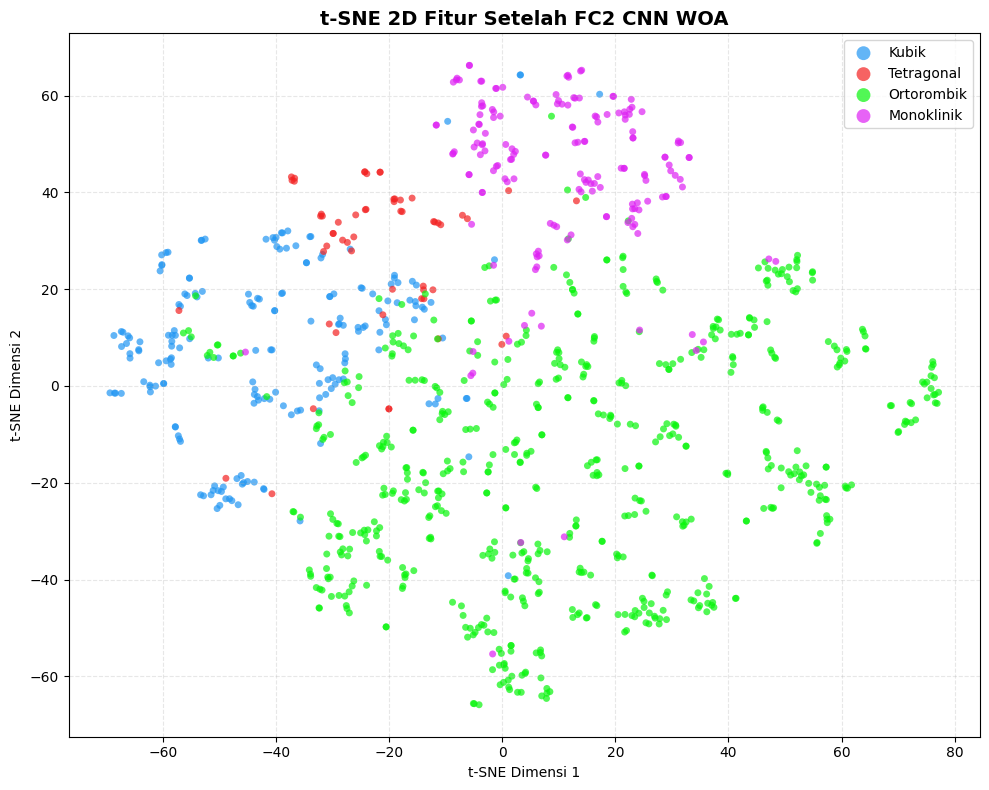

In [20]:
features_cnn = extract_features_after_fc2_before_softmax(model, X_test_cnn)

print(f"   Shape fitur : {features_cnn.shape}")

print("   Menjalankan t-SNE 2D ...")
tsne = TSNE(
    n_components=2,
    random_state=RANDOM_SEED,
    perplexity=10,
    max_iter=1000
)

coords = tsne.fit_transform(features_cnn)

plt.figure(figsize=(10, 8))
plt.suptitle(
    "t-SNE 2D Fitur Setelah FC2 CNN",
    fontsize=14,
    fontweight="bold"
)

for i, (cls_name, color) in enumerate(zip(CLASS_NAMES, PALETTE)):
    mask = y_test_enc == i
    plt.scatter(
        coords[mask, 0],
        coords[mask, 1],
        c=color,
        label=cls_name,
        alpha=0.7,
        s=20,
        edgecolors="none"
    )

plt.xlabel("t-SNE Dimensi 1", fontsize=12, fontweight="bold")
plt.ylabel("t-SNE Dimensi 2", fontsize=12, fontweight="bold")
plt.legend(fontsize=10, markerscale=2)
plt.grid(linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# --- Visualisasi Model CNN WOA ---
features_woa = extract_features_after_fc2_before_softmax(model_woa, X_test_cnn)

print(f"   Shape fitur : {features_woa.shape}")

print("   Menjalankan t-SNE 2D ...")
tsne_woa = TSNE(
    n_components=2,
    random_state=RANDOM_SEED,
    perplexity=10,
    max_iter=1000
)

coords_woa = tsne_woa.fit_transform(features_woa)

plt.figure(figsize=(10, 8))
plt.title(
    "t-SNE 2D Fitur Setelah FC2 CNN WOA",
    fontsize=14,
    fontweight="bold"
)

for i, (cls_name, color) in enumerate(zip(CLASS_NAMES, PALETTE)):
    mask = y_test_enc == i

    plt.scatter(
        coords_woa[mask, 0],
        coords_woa[mask, 1],
        c=color,
        label=cls_name,
        alpha=0.7,
        s=25,
        edgecolors="none"
    )

plt.xlabel("t-SNE Dimensi 1")
plt.ylabel("t-SNE Dimensi 2")
plt.legend(fontsize=10, markerscale=2)
plt.grid(linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


t-SNE 3D

   Shape fitur : (1029, 16)
   Menjalankan t-SNE 3D ...


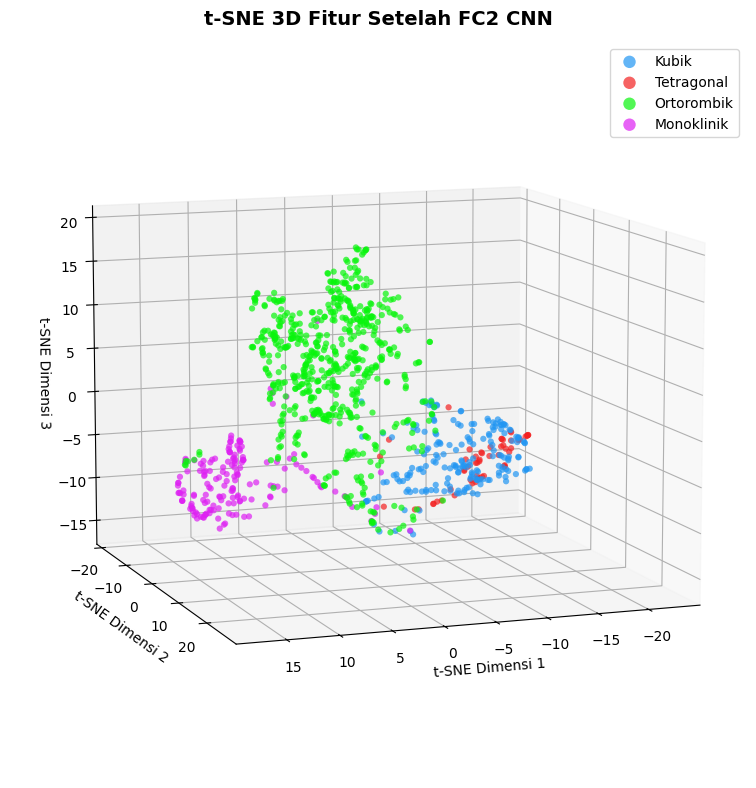

   Shape fitur : (1029, 64)
   Menjalankan t-SNE 3D ...


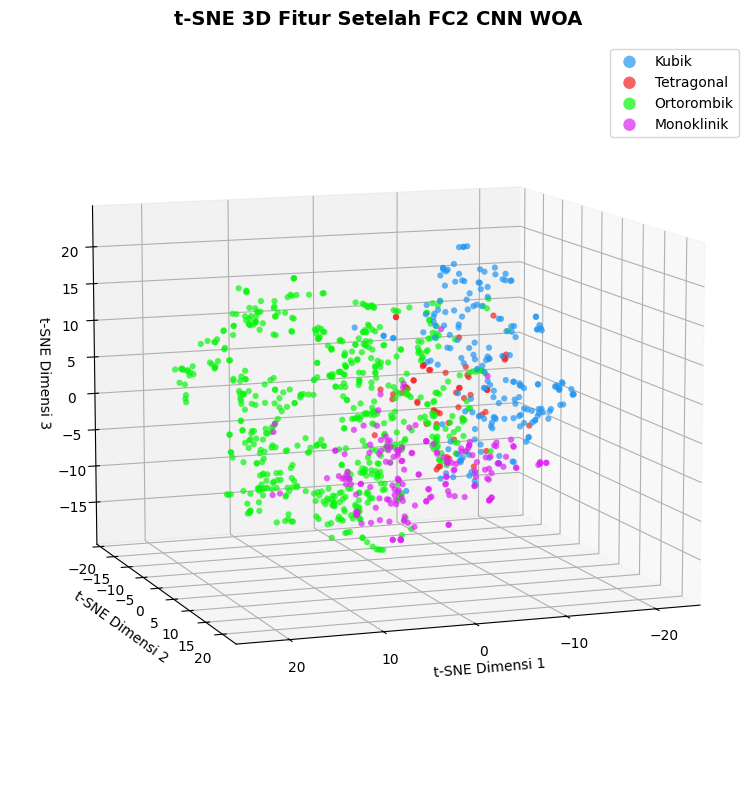

In [19]:
features = extract_features_after_fc2_before_softmax(model, X_test_cnn)
print(f"   Shape fitur : {features.shape}")

print("   Menjalankan t-SNE 3D ...")
tsne = TSNE(
    n_components=3,
    random_state=RANDOM_SEED,
    perplexity=10,
    max_iter=1000
)
coords = tsne.fit_transform(features)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
fig.suptitle(
    "t-SNE 3D Fitur Setelah FC2 CNN",
    fontsize=14,
    fontweight="bold"
)

for i, (cls_name, color) in enumerate(zip(CLASS_NAMES, PALETTE)):
    mask = y_test_enc == i
    ax.scatter(
        coords[mask, 0],
        coords[mask, 1],
        coords[mask, 2],
        c=color,
        label=cls_name,
        alpha=0.7,
        s=20,
        edgecolors="none"
    )

ax.set_xlabel("t-SNE Dimensi 1")
ax.set_ylabel("t-SNE Dimensi 2")
ax.set_zlabel("t-SNE Dimensi 3")
ax.legend(fontsize=10, markerscale=2)
ax.grid(linestyle="--", alpha=0.3)
ax.view_init(elev=10, azim=70)
plt.tight_layout()
plt.show()

features_woa = extract_features_after_fc2_before_softmax(model_woa, X_test_cnn)
print(f"   Shape fitur : {features_woa.shape}")

print("   Menjalankan t-SNE 3D ...")
tsne_woa = TSNE(
    n_components=3,
    random_state=RANDOM_SEED,
    perplexity=10,
    max_iter=1000
)
coords_woa = tsne_woa.fit_transform(features_woa)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
fig.suptitle(
    "t-SNE 3D Fitur Setelah FC2 CNN WOA",
    fontsize=14,
    fontweight="bold"
)

for i, (cls_name, color) in enumerate(zip(CLASS_NAMES, PALETTE)):
    mask = y_test_enc == i
    ax.scatter(
        coords_woa[mask, 0],
        coords_woa[mask, 1],
        coords_woa[mask, 2],
        c=color,
        label=cls_name,
        alpha=0.7,
        s=20,
        edgecolors="none"
    )

ax.set_xlabel("t-SNE Dimensi 1")
ax.set_ylabel("t-SNE Dimensi 2")
ax.set_zlabel("t-SNE Dimensi 3")
ax.view_init(elev=10, azim=70) 
ax.legend(fontsize=10, markerscale=2)
ax.grid(linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


